# 06 - LSTM/GRU Sequence Autoencoders (Step 6)

**Purpose:** the collective/temporal corner of the five-method comparison, and
the last method family the study needs. Recurrent autoencoders are trained to
rebuild ordinary 6-hour windows of a sensor's own history, reading each window
as an ordered sequence rather than as a flat vector. Two variants are run as
genuinely separate methods, `lstm_ae` and `gru_ae`, never combined into one
entry.

This is the **only** method in the roster that models temporal order
explicitly, and Step 5 was built to be its control. Same 12 stations, same
three sensors, same prepared data, same 36-bin window, same time-based split,
the same scaler, optimizer and stopping rule, and the same percentile
threshold rule -- all of it shared through `uema.reconstruct`. Step 5 received
the window flattened, so its network could not know its inputs were ordered in
time. This notebook hands the identical numbers to models that can use that
order. Everything except the architecture is held fixed, which is what lets
Step 7 read a Step 5 vs Step 6 difference as the contribution of recurrence
rather than of reconstruction-based scoring in general.

Nothing here is validated against ground truth -- this project has no labels.
This is the fifth and final comparable input to Step 7.

Two Step 5 results set what this notebook has to measure:

- Step 5's flagged set was only 0.60-0.78 self-consistent across seeds. **An
  LSTM-vs-GRU difference smaller than either variant's own seed spread is not
  a finding**, so the seed pass is what makes that comparison readable at all.
- Converging Step 5's models properly cut held-out loss substantially and moved
  the flagged sets almost not at all. Reconstruction quality and flagged-set
  identity are close to independent here, so a variant that merely
  reconstructs better must not be reported as detecting differently.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from uema.agree import (
    align_by_sensor,
    jaccard_by_sensor,
    jaccard_matrix,
    matched_budget_flags,
    native_flags,
)
from uema.detect import SCHEMA_COLUMNS, build_detection_table
from uema.reconstruct import (
    BOTTLENECK,
    BOTTLENECK_GRID,
    CONTROL_BINS,
    MAX_EPOCHS,
    SEEDS,
    SEQUENCE_BINS,
    THRESHOLD_GRID,
    GRUAutoencoder,
    LSTMAutoencoder,
    bottleneck_for,
    percentile_threshold,
    reconstruction_error,
    scale_windows,
    sliding_windows,
    time_split,
    train_reconstructor,
)
from uema.silver import consolidate_stations, fill_gaps
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()
torch.set_num_threads(4)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

REPORT_DIR = Path("..") / "reports" / "data_audit"
DETECT_DIR = Path("..") / "reports" / "detections"
DETECT_DIR.mkdir(parents=True, exist_ok=True)

# Resume cache for the multi-hour fitting cell below. Under `data/`, which is
# git-ignored, so nothing bulky or derived lands in the repository.
CACHE_DIR = Path("..") / "data" / "stations" / "processed" / "step6_runs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Data prep

Identical to Steps 1-5: the same 12 in-scope stations (GO + CONDITIONAL-GO,
read from `station_recommendation.csv`, never hardcoded), each on its own
joint-span 10-minute grid with short gaps (<=6h) linearly bridged and longer
gaps left as `NaN`. Sharing the prepared data with the other detectors is what
makes Step 7's per-timestamp comparison meaningful -- a difference between
methods then reflects the methods, not different preprocessing.

In [2]:
recommendation = pd.read_csv(
    REPORT_DIR / "station_recommendation.csv", index_col="station"
)
station_frames = consolidate_stations(recommendation)
station_frames = {
    station: fill_gaps(df.resample("10min").mean(), max_gap="6h")
    for station, df in station_frames.items()
}
sorted(station_frames)

['recinto-esparza',
 'recinto-santa-cruz',
 'sede-atlantico_turrialba',
 'sede-caribe_limon',
 'sede-central_finca-1',
 'sede-central_finca-2',
 'sede-central_finca-3',
 'sede-central_losic-norte-1',
 'sede-central_losic-norte-2',
 'sede-central_sabanilla',
 'sede-guanacaste_liberia',
 'sede-sur_golfito']

## Methodology

**Window: 36 bins (6h), centered, stride 1 -- inherited, not chosen.**
`uema.reconstruct.SEQUENCE_BINS` is read rather than restated. Step 4b showed
window length is a first-order confound: re-running the density methods at 6h
instead of their native 1h, changing nothing else, dropped each method's
agreement with *itself* to 0.053 (LOF) and 0.242 (Isolation Forest). At
mismatched windows a Step 5 vs Step 6 comparison would measure the window
rather than the recurrence it exists to isolate.

**Input: the raw window as a sequence**, one value per timestep, which is the
whole difference from Step 5. The recurrent layers see the actual temporal
ordering; Step 5's dense network saw the same numbers flattened.

**Univariate, fit per station x sensor**, as in Steps 3-5. Step 1 found lag-0
correlation between the three sensors weak everywhere (`|r| <= 0.14`), so
there is nothing to gain from a joint fit, and keeping the scope fixed means a
Step 7 disagreement reflects the method and not a change in what was fit to
what. The plan's joint-feature case therefore never arises and `sensor` keeps
its plain meaning.

**Architecture:** encoder RNN over the 36 bins, its final hidden state
projected to an 8-dimensional latent; the latent repeated across all 36 steps,
a decoder RNN over that repetition, and a per-step projection back to one
value. One recurrent layer per side, hidden width 17 (the geometric mean of
input and latent, the same rule `DenseAutoencoder` uses, so both architectures
funnel identically at any window length). No dropout: these models hold a few
thousand parameters and Step 5 found this data underfits rather than overfits.
`nn.LSTM` and `nn.GRU` are the only difference between the two variants.

**Parameter counts are not matched and cannot be** while window and latent are
both held fixed -- dense 1,574, GRU 3,171, LSTM 4,123. Holding the input
representation and the 4.5:1 compression fixed is the comparison that isolates
recurrence; matching parameter counts instead would force a different latent
size and reintroduce the confound Step 4b warned about. This is reported, not
hidden.

**Threshold:** the 99th percentile of each cell's *validation* reconstruction
error, as in Step 5, with 90th and 95th reported alongside as a sensitivity
analysis rather than presenting one as validated. This fixes the alarm rate by
construction rather than discovering it, unlike the published cutoffs Steps 3-4
use, and Step 7's native-threshold view must say so.

**Device.** These models run on the GPU when one is available. A recurrent
layer walks the window one bin at a time, which is the case a fused kernel
exists for: measured on this machine, CUDA is 3.3x faster than CPU for the
LSTM and 10.1x for the GRU, while Step 5's dense model is *slower* on CUDA
(0.7x) and stays on CPU. Fits were verified bit-identical across repeated runs
on both devices before this was adopted; the device is a throughput choice
that must not touch the numbers within a step, and all Step 6 runs use one
device so no comparison here spans two.

## Fitting

Two architectures over three passes. Every run is cached to disk under `data/`
(git-ignored) keyed by its full run tuple, so this cell is resumable -- it
takes several hours end to end, and losing all of it to one interruption would
be the only genuinely expensive failure in this project.

| pass | scope | runs per architecture |
|---|---|---|
| primary + seed stability | all 36 cells | 5 (seeds 0-4) |
| window control | all 36 cells | 1 (6 bins) |
| bottleneck ablation | 12-cell subset | 3 (latents 2, 4, 16) |

The first two passes run over the whole network because they carry the
step's load-bearing claims: the primary table feeds Step 7, and the seed
spread is what makes the LSTM-vs-GRU comparison interpretable. The bottleneck
ablation runs over a stratified subset of four stations spanning the range of
training-set sizes -- Step 5 already swept latent size over the full network
on the same data and windows, so this pass checks whether that answer carries
to recurrent models rather than establishing it from scratch. **The subset is
a stated scope limit, not a silent one.**

In [3]:
SENSORS = ("pressure", "precipitation", "luminous_intensity")
ARCHS = {"lstm_ae": LSTMAutoencoder, "gru_ae": GRUAutoencoder}

PRIMARY = (SEQUENCE_BINS, BOTTLENECK, 0)
CONTROL = (CONTROL_BINS, bottleneck_for(CONTROL_BINS), 0)

NETWORK_RUNS = [(SEQUENCE_BINS, BOTTLENECK, seed) for seed in SEEDS] + [CONTROL]
SUBSET_RUNS = [(SEQUENCE_BINS, d, 0) for d in BOTTLENECK_GRID if d != BOTTLENECK]

# Four stations spanning the range of training-set sizes, picked from Step 5's
# own record of how many windows each cell trained on rather than by name, so
# the subset tracks the data instead of a hardcoded judgement.
step5_summary = pd.read_csv(DETECT_DIR / "step5_summary.csv")
by_size = step5_summary.groupby("station")["n_train"].median().sort_values()
ABLATION_STATIONS = tuple(by_size.index[np.linspace(0, len(by_size) - 1, 4).round().astype(int)])
ABLATION_STATIONS

('sede-central_losic-norte-2',
 'sede-central_finca-1',
 'recinto-santa-cruz',
 'sede-atlantico_turrialba')

In [4]:
def cache_path(key) -> Path:
    station, sensor, arch, window, bottleneck, seed = key
    return CACHE_DIR / f"{station}__{sensor}__{arch}__w{window}_d{bottleneck}_s{seed}.npz"


def fit_cell(series: pd.Series, arch: str, window: int, bottleneck: int, seed: int) -> dict | None:
    '''Train one recurrent autoencoder on one station x sensor and score every window.'''
    matrix, centers = sliding_windows(series, window)
    if len(matrix) == 0:
        return None

    train_mask = time_split(centers)
    scaled = scale_windows(matrix, train_mask)
    model = ARCHS[arch](window, bottleneck)
    history = train_reconstructor(model, scaled, train_mask, seed=seed, device=DEVICE)
    score = reconstruction_error(model, scaled, centers, device=DEVICE)

    return {
        "score": score,
        "threshold": percentile_threshold(score, train_mask),
        "train_mask": train_mask,
        "n_train": int(train_mask.sum()),
        "n_scored": len(score),
        "epochs": len(history["train"]),
        "best_val": float(np.nanmin(history["val"])),
    }


def save_fit(path: Path, fit: dict) -> None:
    np.savez_compressed(
        path,
        timestamps=fit["score"].index.to_numpy().astype("datetime64[ns]").astype("int64"),
        score=fit["score"].to_numpy(),
        train_mask=fit["train_mask"],
        scalars=np.array([fit["threshold"], fit["epochs"], fit["best_val"]]),
    )


def load_fit(path: Path) -> dict:
    z = np.load(path)
    index = pd.DatetimeIndex(z["timestamps"].astype("datetime64[ns]"))
    threshold, epochs, best_val = z["scalars"]
    return {
        "score": pd.Series(z["score"], index=index),
        "threshold": float(threshold),
        "train_mask": z["train_mask"],
        "n_train": int(z["train_mask"].sum()),
        "n_scored": len(index),
        "epochs": int(epochs),
        "best_val": float(best_val),
    }

In [5]:
%%time
results = {}
for station, df10 in sorted(station_frames.items()):
    plan = list(NETWORK_RUNS)
    if station in ABLATION_STATIONS:
        plan += SUBSET_RUNS
    for sensor in SENSORS:
        for arch in ARCHS:
            for window, bottleneck, seed in plan:
                key = (station, sensor, arch, window, bottleneck, seed)
                path = cache_path(key)
                if path.exists():
                    results[key] = load_fit(path)
                    continue
                fit = fit_cell(df10[sensor], arch, window, bottleneck, seed)
                if fit is not None:
                    save_fit(path, fit)
                    results[key] = fit
    print(f"{station:<32} {len(results):>4} runs done", flush=True)

len(results)

recinto-esparza                    36 runs done


recinto-santa-cruz                 90 runs done


sede-atlantico_turrialba          144 runs done


sede-caribe_limon                 180 runs done


sede-central_finca-1              234 runs done


...

sede-central_sabanilla            432 runs done


sede-guanacaste_liberia           468 runs done


sede-sur_golfito                  504 runs done


CPU times: user 1.24 s, sys: 156 ms, total: 1.4 s
Wall time: 1.4 s


504

### Did every cell actually train?

Two ways a fit can be quietly wrong rather than loudly broken, both carried
over from Step 5.

The first is a model that produces constant output where training windows are
too few -- a detector that silently degenerates instead of erroring. The
assertion below catches it.

The second is a model cut off mid-convergence. `MAX_EPOCHS` is a safety bound
that early stopping is meant to reach first, so a run that ends by exhausting
it was still learning when training stopped. If a meaningful share hit the cap,
the cap rather than convergence is setting what these scores are.

In [6]:
fit_health = pd.DataFrame(
    [
        {
            "station": station,
            "sensor": sensor,
            "method": arch,
            "n_train": fit["n_train"],
            "n_scored": fit["n_scored"],
            "epochs": fit["epochs"],
            "ended_early": fit["epochs"] < MAX_EPOCHS,
            "best_val_loss": fit["best_val"],
            "score_std": float(fit["score"].std()),
            "threshold": fit["threshold"],
        }
        for (station, sensor, arch, window, bottleneck, seed), fit in results.items()
        if (window, bottleneck, seed) == PRIMARY
    ]
)

assert (fit_health["score_std"] > 0).all(), "a cell produced a constant score vector"

print(f"ended by early stopping: {fit_health['ended_early'].sum()}/{len(fit_health)}")
print(f"hit the {MAX_EPOCHS}-epoch cap:  {(~fit_health['ended_early']).sum()}/{len(fit_health)}")
print(fit_health.groupby("method")["epochs"].describe().round(1).to_string())

fit_health.sort_values("epochs", ascending=False).head(8)

ended by early stopping: 72/72
hit the 500-epoch cap:  0/72
         count   mean    std   min   25%   50%    75%    max
method                                                      
gru_ae    36.0  121.5  113.6  19.0  34.8  74.5  226.0  422.0
lstm_ae   36.0  107.2   93.3  17.0  45.0  72.0  143.2  354.0


,station,sensor,method,n_train,n_scored,epochs,ended_early,best_val_loss,score_std,threshold
47,sede-central_losic-norte-1,luminous_intensity,gru_ae,14218,17961,422,True,0.012801,0.021891,0.091004
59,sede-central_sabanilla,luminous_intensity,gru_ae,12268,15389,378,True,0.036627,0.049369,0.224819
70,sede-sur_golfito,luminous_intensity,lstm_ae,60296,77633,354,True,0.008563,0.015730,0.066074
34,sede-central_finca-2,luminous_intensity,lstm_ae,34263,44775,324,True,0.032158,0.049389,0.237427
29,sede-central_finca-1,luminous_intensity,gru_ae,30376,38371,305,True,0.037772,0.058959,0.267702
4,recinto-esparza,luminous_intensity,lstm_ae,69620,87510,299,True,0.009175,0.017663,0.085655
16,sede-atlantico_turrialba,luminous_intensity,lstm_ae,76668,95651,299,True,0.005748,0.010663,0.047620
41,sede-central_finca-3,luminous_intensity,gru_ae,37022,52751,283,True,0.051525,0.092619,0.451998


## Primary detection table

The delivered methods: 6h window, latent 8, seed 0, each flagged above the
99th percentile of its own cell's validation reconstruction error. `lstm_ae`
and `gru_ae` are two separate method entries throughout.

The assertion on timestamps is load-bearing. Step 5 and Step 6 use the same
window rule over the same prepared data, so each cell must score exactly the
same set of centre timestamps. Step 7 joins the methods on that timestamp, and
a silent mismatch would quietly shrink every agreement number it computes.

In [7]:
detections = pd.concat(
    [
        build_detection_table(fit["score"], station, sensor, arch, fit["threshold"])
        for (station, sensor, arch, window, bottleneck, seed), fit in results.items()
        if (window, bottleneck, seed) == PRIMARY
    ],
    ignore_index=True,
)
assert list(detections.columns) == SCHEMA_COLUMNS
assert set(detections["method"]) == {"lstm_ae", "gru_ae"}

step5 = pd.read_parquet(DETECT_DIR / "step5_autoencoder.parquet")
step5_stamps = step5.groupby(["station", "sensor"])["timestamp"].agg(frozenset)
for arch, group in detections.groupby("method"):
    stamps = group.groupby(["station", "sensor"])["timestamp"].agg(frozenset)
    assert stamps.equals(step5_stamps), f"{arch} does not score Step 5's timestamps exactly"

detections.to_parquet(DETECT_DIR / "step6_lstm_gru.parquet", index=False)
detections.shape

(3822798, 6)

In [8]:
summary = (
    detections.groupby(["station", "sensor", "method"])
    .agg(n_scored=("flagged", "size"), n_flagged=("flagged", "sum"))
    .assign(flagged_rate=lambda d: d["n_flagged"] / d["n_scored"])
    .reset_index()
    .merge(
        fit_health[["station", "sensor", "method", "n_train", "epochs", "ended_early", "best_val_loss"]],
        on=["station", "sensor", "method"],
    )
)
summary.to_csv(DETECT_DIR / "step6_summary.csv", index=False)

summary.pivot_table(index="station", columns=["method", "sensor"], values="flagged_rate")

method                                 gru_ae                                    lstm_ae                        
sensor                     luminous_intensity precipitation  pressure luminous_intensity precipitation  pressure
station                                                                                                         
recinto-esparza                      0.009473      0.014567  0.012513           0.008159      0.014204  0.012913
recinto-santa-cruz                   0.011746      0.009808  0.028969           0.013571      0.009353  0.018997
sede-atlantico_turrialba             0.014218      0.003761  0.007705           0.011260      0.004087  0.007977
sede-caribe_limon                    0.004236      0.005520  0.001839           0.004565      0.005598  0.002824
sede-central_finca-1                 0.008548      0.010465  0.005916           0.012197      0.010019  0.005760
sede-central_finca-2                 0.006499      0.012722  0.017197           0.006812      0.010905  0.014584
sede-central_finca-3                 0.007602      0.017667  0.004303           0.007734      0.014995  0.003621
sede-central_losic-norte-1           0.012026      0.030510  0.010746           0.013585      0.032487  0.011024
sede-central_losic-norte-2           0.023877      0.004483  0.004859           0.021113      0.004483  0.004943
sede-central_sabanilla               0.004744      0.011087  0.006303           0.005004      0.010382  0.005913
sede-guanacaste_liberia              0.007904      0.005378  0.019866           0.007371      0.005402  0.019930
sede-sur_golfito                     0.014285      0.013739  0.012958           0.013435      0.013262  0.010807

## Threshold sensitivity

The cutoff percentile has no label to justify it, so the flagged rate is
reported at three of them rather than presenting one as validated -- the plan
requires this of Step 6 explicitly. No refit is involved: the cutoff is a
quantile of stored scores. Because it is taken over the validation split alone,
the resulting rate over *all* rows is not mechanically `1 - pct`, and how far
it departs says whether the later part of a record reconstructs like the
earlier part.

In [9]:
sensitivity_rows = []
for (station, sensor, arch, window, bottleneck, seed), fit in results.items():
    if (window, bottleneck, seed) != PRIMARY:
        continue
    for pct in THRESHOLD_GRID:
        cutoff = percentile_threshold(fit["score"], fit["train_mask"], pct)
        sensitivity_rows.append(
            {
                "station": station,
                "sensor": sensor,
                "method": arch,
                "percentile": pct,
                "cutoff": cutoff,
                "rate_overall": float((fit["score"] > cutoff).mean()),
            }
        )

threshold_sensitivity = pd.DataFrame(sensitivity_rows)
threshold_sensitivity.to_csv(DETECT_DIR / "step6_threshold_sensitivity.csv", index=False)

threshold_sensitivity.pivot_table(
    index=["method", "sensor"], columns="percentile", values="rate_overall"
)

percentile                      0.90      0.95      0.99
method  sensor                                          
gru_ae  luminous_intensity  0.097059  0.047696  0.010430
        precipitation       0.085471  0.044769  0.011642
        pressure            0.079876  0.042108  0.011098
lstm_ae luminous_intensity  0.098763  0.047730  0.010400
        precipitation       0.086407  0.045551  0.011265
        pressure            0.072549  0.038031  0.009941

## Robustness pass 1 - seed stability

Five fits per architecture over the whole network, differing only in weight
initialization and batch order. This is the number every claim in the
LSTM-vs-GRU section below is measured against: a difference between the two
architectures that is smaller than either one's own spread across seeds is
initialization, not architecture.

Step 5's reference values on the same data and window: 0.780 `precipitation`,
0.606 `luminous_intensity`, 0.602 `pressure`.

Each variant is treated as its own "method" so the `uema.agree` primitives
apply unchanged. Flags are each fit's own 99th-percentile cutoff, an equal
alarm budget by construction, so these numbers need no separate matched-budget
view.

In [10]:
def variant_table(method_of, keep) -> pd.DataFrame:
    '''Long-form detection table over a set of runs, one `method` name per variant.'''
    return pd.concat(
        [
            build_detection_table(fit["score"], key[0], key[1], method_of(key), fit["threshold"])
            for key, fit in results.items()
            if keep(key)
        ],
        ignore_index=True,
    )


def aligned_flags(runs: pd.DataFrame) -> pd.DataFrame:
    '''Native flags over the rows every variant scored, aligned per sensor.

    `align_by_sensor` rather than `align_scores` throughout, per Step 5: a
    listwise pooled call is what once collapsed an analysis to a single
    channel. Every roster here is uniform across sensors, so the two agree --
    using the safe one anyway is what keeps that true by construction rather
    than by inspection.
    '''
    aligned = align_by_sensor(runs)
    index = aligned[next(iter(aligned))].index
    for sensor, frame in list(aligned.items())[1:]:
        index = index.append(frame.index)
    return native_flags(runs, index)


seed_stability = []
seed_pairs_all = []
for arch in ARCHS:
    runs = variant_table(
        lambda key: f"seed_{key[5]}",
        lambda key, arch=arch: key[2] == arch and key[3] == SEQUENCE_BINS and key[4] == BOTTLENECK,
    )
    pairs = jaccard_by_sensor(aligned_flags(runs)).assign(method=arch)
    seed_pairs_all.append(pairs)
    seed_stability.append(
        pairs.groupby("sensor")["jaccard"]
        .agg(mean_pairwise_jaccard="mean", min_pairwise_jaccard="min", n_pairs="size")
        .assign(method=arch)
        .reset_index()
    )

seed_stability = pd.concat(seed_stability, ignore_index=True)
seed_stability.to_csv(DETECT_DIR / "step6_seed_stability.csv", index=False)
seed_stability.pivot_table(index="sensor", columns="method", values="mean_pairwise_jaccard")

method,gru_ae,lstm_ae
sensor,,
luminous_intensity,0.582397,0.543715
precipitation,0.781948,0.798567
pressure,0.697371,0.756765


## Robustness pass 2 - window control

The control Step 4b established and Step 5 repeated: refit at a second window
length, change nothing else, and report the method's agreement **with itself**.
Reference points -- LOF 0.053, Isolation Forest 0.242, Autoencoder 0.187.

The control window is 1h, which is also Step 4's window, so this doubles as a
window-matched comparison against the density methods. Compression is held at
4.5:1 rather than the latent size at 8, so the window is the only thing that
varies; at 6 inputs a latent of 8 would be over-complete and the model could
copy its input straight through.

In [11]:
window_control = []
for arch in ARCHS:
    runs = variant_table(
        lambda key: f"window_{key[3]}",
        lambda key, arch=arch: key[2] == arch and key[5] == 0
        and (key[3], key[4], key[5]) in (PRIMARY, CONTROL),
    )
    flags = aligned_flags(runs)
    per_sensor = jaccard_by_sensor(flags).assign(method=arch)
    overall = pd.DataFrame([{
        "sensor": "all",
        "method_a": f"window_{SEQUENCE_BINS}",
        "method_b": f"window_{CONTROL_BINS}",
        "jaccard": jaccard_matrix(flags).iloc[0, 1],
        "method": arch,
    }])
    window_control.append(pd.concat([per_sensor, overall], ignore_index=True))

window_control = pd.concat(window_control, ignore_index=True)
window_control.to_csv(DETECT_DIR / "step6_window_control.csv", index=False)
window_control

,sensor,method_a,method_b,jaccard,method
0,luminous_intensity,window_36,window_6,0.145137,lstm_ae
1,precipitation,window_36,window_6,0.212883,lstm_ae
2,pressure,window_36,window_6,0.252084,lstm_ae
3,all,window_36,window_6,0.204692,lstm_ae
4,luminous_intensity,window_36,window_6,0.141999,gru_ae
5,precipitation,window_36,window_6,0.214008,gru_ae
6,pressure,window_36,window_6,0.258603,gru_ae
7,all,window_36,window_6,0.205982,gru_ae


## Robustness pass 3 - bottleneck ablation (12-cell subset)

Latent size swept over the four-value grid, seed held at 0, on the four
stations spanning the range of training-set sizes. Step 5 ran this sweep over
the full network on the same data and windows; the question here is whether
its answer carries to recurrent models, not whether latent size matters at
all. **Scope limit: four of twelve stations.**

In [12]:
bottleneck_ablation = []
for arch in ARCHS:
    runs = variant_table(
        lambda key: f"latent_{key[4]}",
        lambda key, arch=arch: key[2] == arch and key[0] in ABLATION_STATIONS
        and key[3] == SEQUENCE_BINS and key[5] == 0,
    )
    bottleneck_ablation.append(jaccard_by_sensor(aligned_flags(runs)).assign(method=arch))

bottleneck_ablation = pd.concat(bottleneck_ablation, ignore_index=True)
bottleneck_ablation["stations"] = len(ABLATION_STATIONS)
bottleneck_ablation.to_csv(DETECT_DIR / "step6_bottleneck_ablation.csv", index=False)

bottleneck_ablation[bottleneck_ablation["method_a"] == f"latent_{BOTTLENECK}"].pivot_table(
    index=["method", "sensor"], columns="method_b", values="jaccard"
)

,method_b
method,sensor


## LSTM vs GRU

The comparison this step adds, and the one the seed pass exists to make
readable. Both variants see the same windows, the same split, the same scaler,
the same optimizer and stopping rule, and the same threshold rule; `nn.LSTM`
against `nn.GRU` is the only difference between them.

The test is a pooled one rather than a comparison of two averages. All ten
fits -- five seeds of each architecture -- are aligned together, every one of
the 45 pairs is scored, and the pairs are then partitioned into three groups:
two LSTM fits, two GRU fits, or one of each. If the cross-architecture group
does not separate from the two within-architecture groups, then swapping
`nn.LSTM` for `nn.GRU` moves the flagged set no more than re-running the same
architecture with a different seed, and the architectures are not
distinguishable in this data.

Comparing group *means* alone would not support that conclusion: Step 5
established that a few hundredths of Jaccard is within what initialization
alone produces, so a gap of that size between two means is not evidence. The
ranges are therefore reported alongside, and the question asked of them is
whether the distributions overlap, not whether one mean is larger.

Reconstruction quality is reported separately from flagged-set identity on
purpose: Step 5 found the two close to independent, so a variant that
reconstructs better must not be reported as detecting better.

In [13]:
# All ten fits aligned together, so every pair is scored over one row set.
both = variant_table(
    lambda key: f"{key[2]}_seed_{key[5]}",
    lambda key: key[3] == SEQUENCE_BINS and key[4] == BOTTLENECK,
)
both_pairs = jaccard_by_sensor(aligned_flags(both))
both_pairs["kind"] = np.where(
    both_pairs["method_a"].str.startswith("lstm") != both_pairs["method_b"].str.startswith("lstm"),
    "cross-architecture",
    np.where(both_pairs["method_a"].str.startswith("lstm"), "within lstm_ae", "within gru_ae"),
)

lstm_vs_gru = (
    both_pairs.groupby(["sensor", "kind"])["jaccard"]
    .agg(mean="mean", min="min", max="max", n_pairs="size")
    .reset_index()
)
lstm_vs_gru.to_csv(DETECT_DIR / "step6_lstm_vs_gru.csv", index=False)
lstm_vs_gru.pivot_table(index="sensor", columns="kind", values=["mean", "min", "max"]).round(3)

max                                            mean                                             min                             
kind               cross-architecture within gru_ae within lstm_ae cross-architecture within gru_ae within lstm_ae cross-architecture within gru_ae within lstm_ae
sensor                                                                                                                                                            
luminous_intensity              0.667         0.667          0.601              0.542         0.582          0.544              0.447         0.526          0.504
precipitation                   0.795         0.812          0.817              0.771         0.782          0.799              0.748         0.749          0.775
pressure                        0.807         0.813          0.800              0.687         0.697          0.757              0.549         0.545          0.688

In [14]:
# Reconstruction quality, reported separately from the flagged sets above.
fit_health.groupby(["method", "sensor"])["best_val_loss"].describe()[["mean", "50%", "max"]].round(5)

mean      50%       max
method  sensor                                        
gru_ae  luminous_intensity  0.02565  0.02420   0.05153
        precipitation       0.03784  0.02379   0.14813
        pressure            0.85933  0.00666   9.40813
lstm_ae luminous_intensity  0.02807  0.02470   0.07553
        precipitation       0.04158  0.02379   0.16404
        pressure            1.17151  0.00728  13.26870

## Step 5 vs Step 6 - what recurrence changes

The comparison both steps were designed for, at matched window, matched split,
matched scaler, matched optimizer and matched threshold rule. The only thing
that differs is whether the model can use the order of the bins.

Reported two ways, per Step 4b. All three methods here use a 99th-percentile
cutoff, so their alarm budgets already match and the two views should agree
closely -- which is itself worth confirming rather than assuming. Alignment is
per sensor via `align_by_sensor`; `align_scores` is never used, since a listwise
pooled call is what silently collapsed an earlier analysis to one channel.

Step 7 does this properly across all six method entries. This is the narrow
version, restricted to the reconstruction family.

In [15]:
reconstruction = pd.concat([step5, detections], ignore_index=True)
aligned = align_by_sensor(reconstruction)

native = pd.concat(
    [
        jaccard_by_sensor({sensor: native_flags(reconstruction, frame.index, list(frame.columns))})
        for sensor, frame in aligned.items()
    ],
    ignore_index=True,
).assign(view="native")

matched = pd.concat(
    [
        jaccard_by_sensor({sensor: matched_budget_flags(frame)})
        for sensor, frame in aligned.items()
    ],
    ignore_index=True,
).assign(view="matched_budget")

recurrence = pd.concat([native, matched], ignore_index=True)
recurrence.to_csv(DETECT_DIR / "step6_recurrence_comparison.csv", index=False)

recurrence.pivot_table(
    index=["method_a", "method_b"], columns=["view", "sensor"], values="jaccard"
).round(3)

view                     matched_budget                                    native                       
sensor               luminous_intensity precipitation pressure luminous_intensity precipitation pressure
method_a    method_b                                                                                    
autoencoder gru_ae                0.515         0.651    0.335              0.514         0.650    0.375
            lstm_ae               0.379         0.648    0.319              0.376         0.629    0.370
gru_ae      lstm_ae               0.502         0.802    0.724              0.511         0.772    0.695

### What moves a flagged set, ranked

Every control in this step and Step 5 measures the same quantity -- how far a
flagged set moves when one thing is changed -- so they can be put on one
scale. This is the summary Step 7 needs, because it says which differences in
this study are large enough to interpret and which are not.

In [16]:
seed_ref = (
    both_pairs[both_pairs["kind"] != "cross-architecture"]
    .groupby("sensor")["jaccard"].agg(["min", "max"])
)

hierarchy = pd.concat([
    both_pairs.assign(change=both_pairs["kind"].map({
        "within lstm_ae": "reseed the same architecture",
        "within gru_ae": "reseed the same architecture",
        "cross-architecture": "swap LSTM for GRU",
    }))[["sensor", "change", "jaccard"]],
    recurrence[(recurrence["view"] == "matched_budget")
               & (recurrence["method_a"] == "autoencoder")]
    .assign(change="add recurrence (dense vs recurrent)")[["sensor", "change", "jaccard"]],
    window_control[window_control["sensor"] != "all"]
    .assign(change="change the window (36 vs 6 bins)")[["sensor", "change", "jaccard"]],
])

hierarchy_summary = (
    hierarchy.groupby(["change", "sensor"])["jaccard"].mean().unstack().round(3)
    .assign(overall=lambda d: d.mean(axis=1).round(3))
    .sort_values("overall", ascending=False)
)
hierarchy_summary.to_csv(DETECT_DIR / "step6_displacement_hierarchy.csv")
hierarchy_summary

sensor,luminous_intensity,precipitation,pressure,overall
change,,,,
reseed the same architecture,0.563,0.790,0.727,0.693
swap LSTM for GRU,0.542,0.771,0.687,0.667
add recurrence (dense vs recurrent),0.447,0.650,0.327,0.475
change the window (36 vs 6 bins),0.144,0.213,0.255,0.204


## Sanity-check plots

The most confidently-flagged window per sensor for each variant, plotted in
its surrounding context -- a check that these detectors pick up genuinely
irregular episodes rather than a systematic artifact (every gap edge, every
sunrise) before the table is trusted as an input to Step 7.

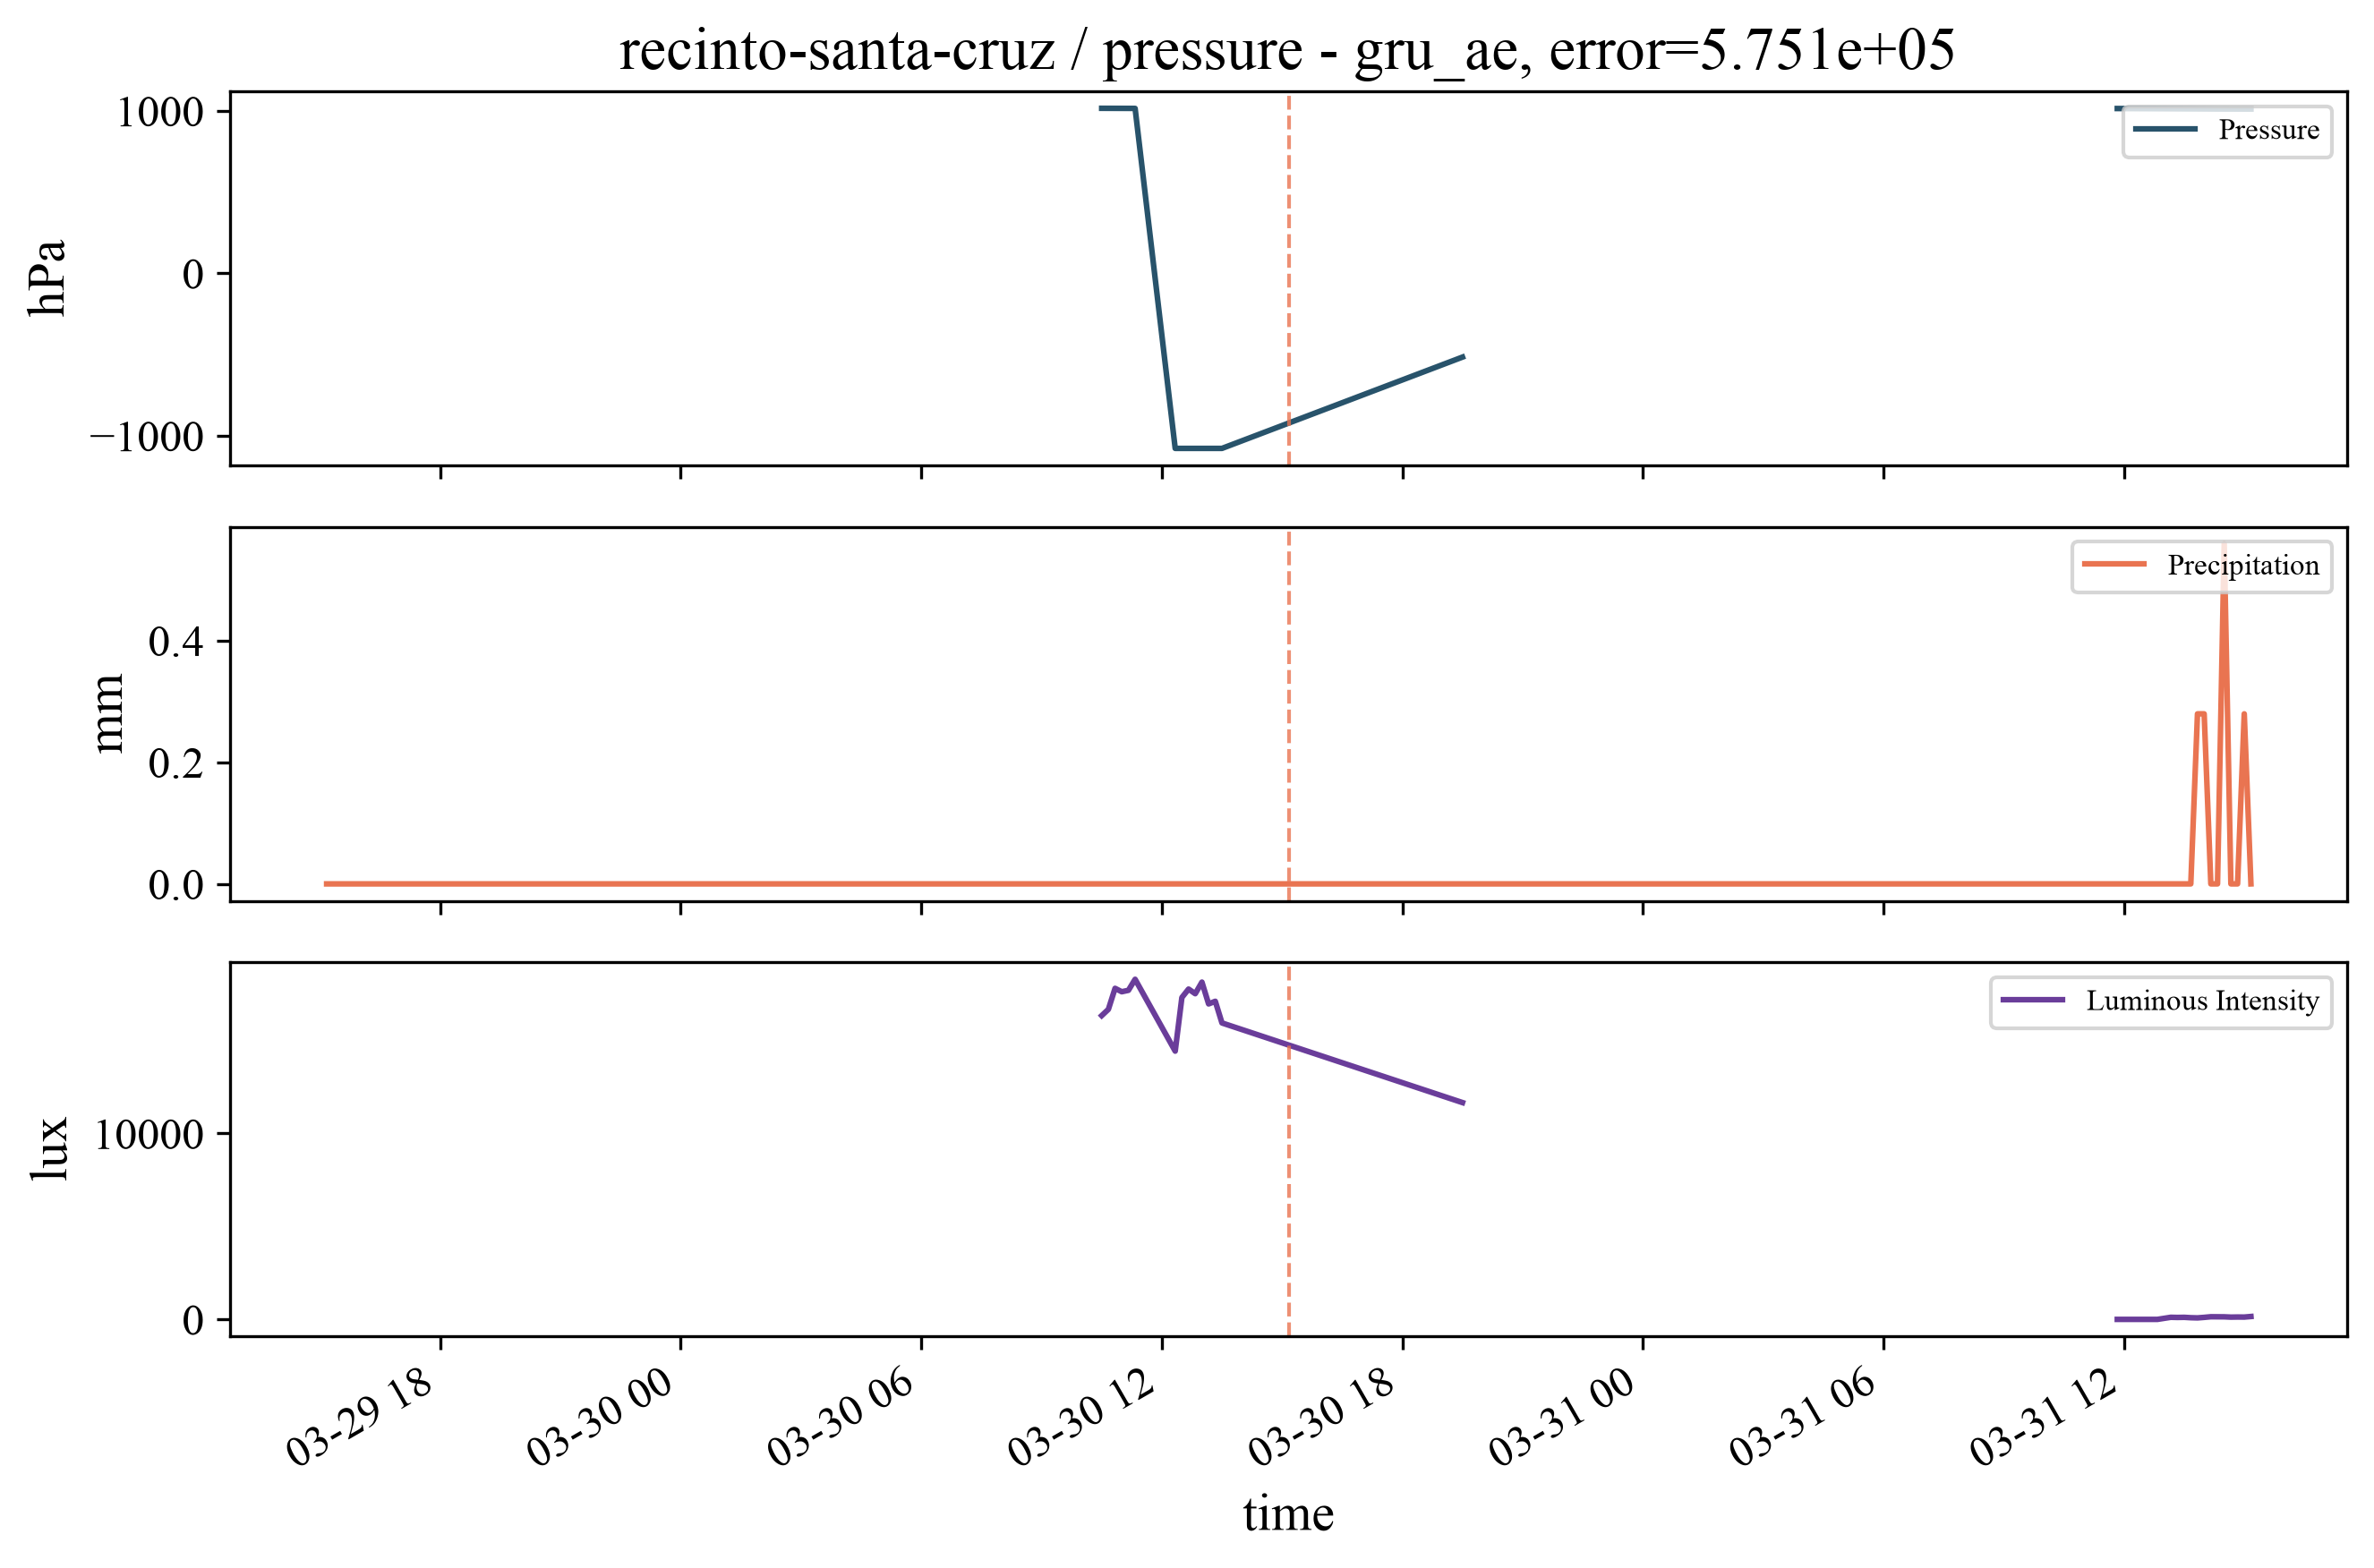

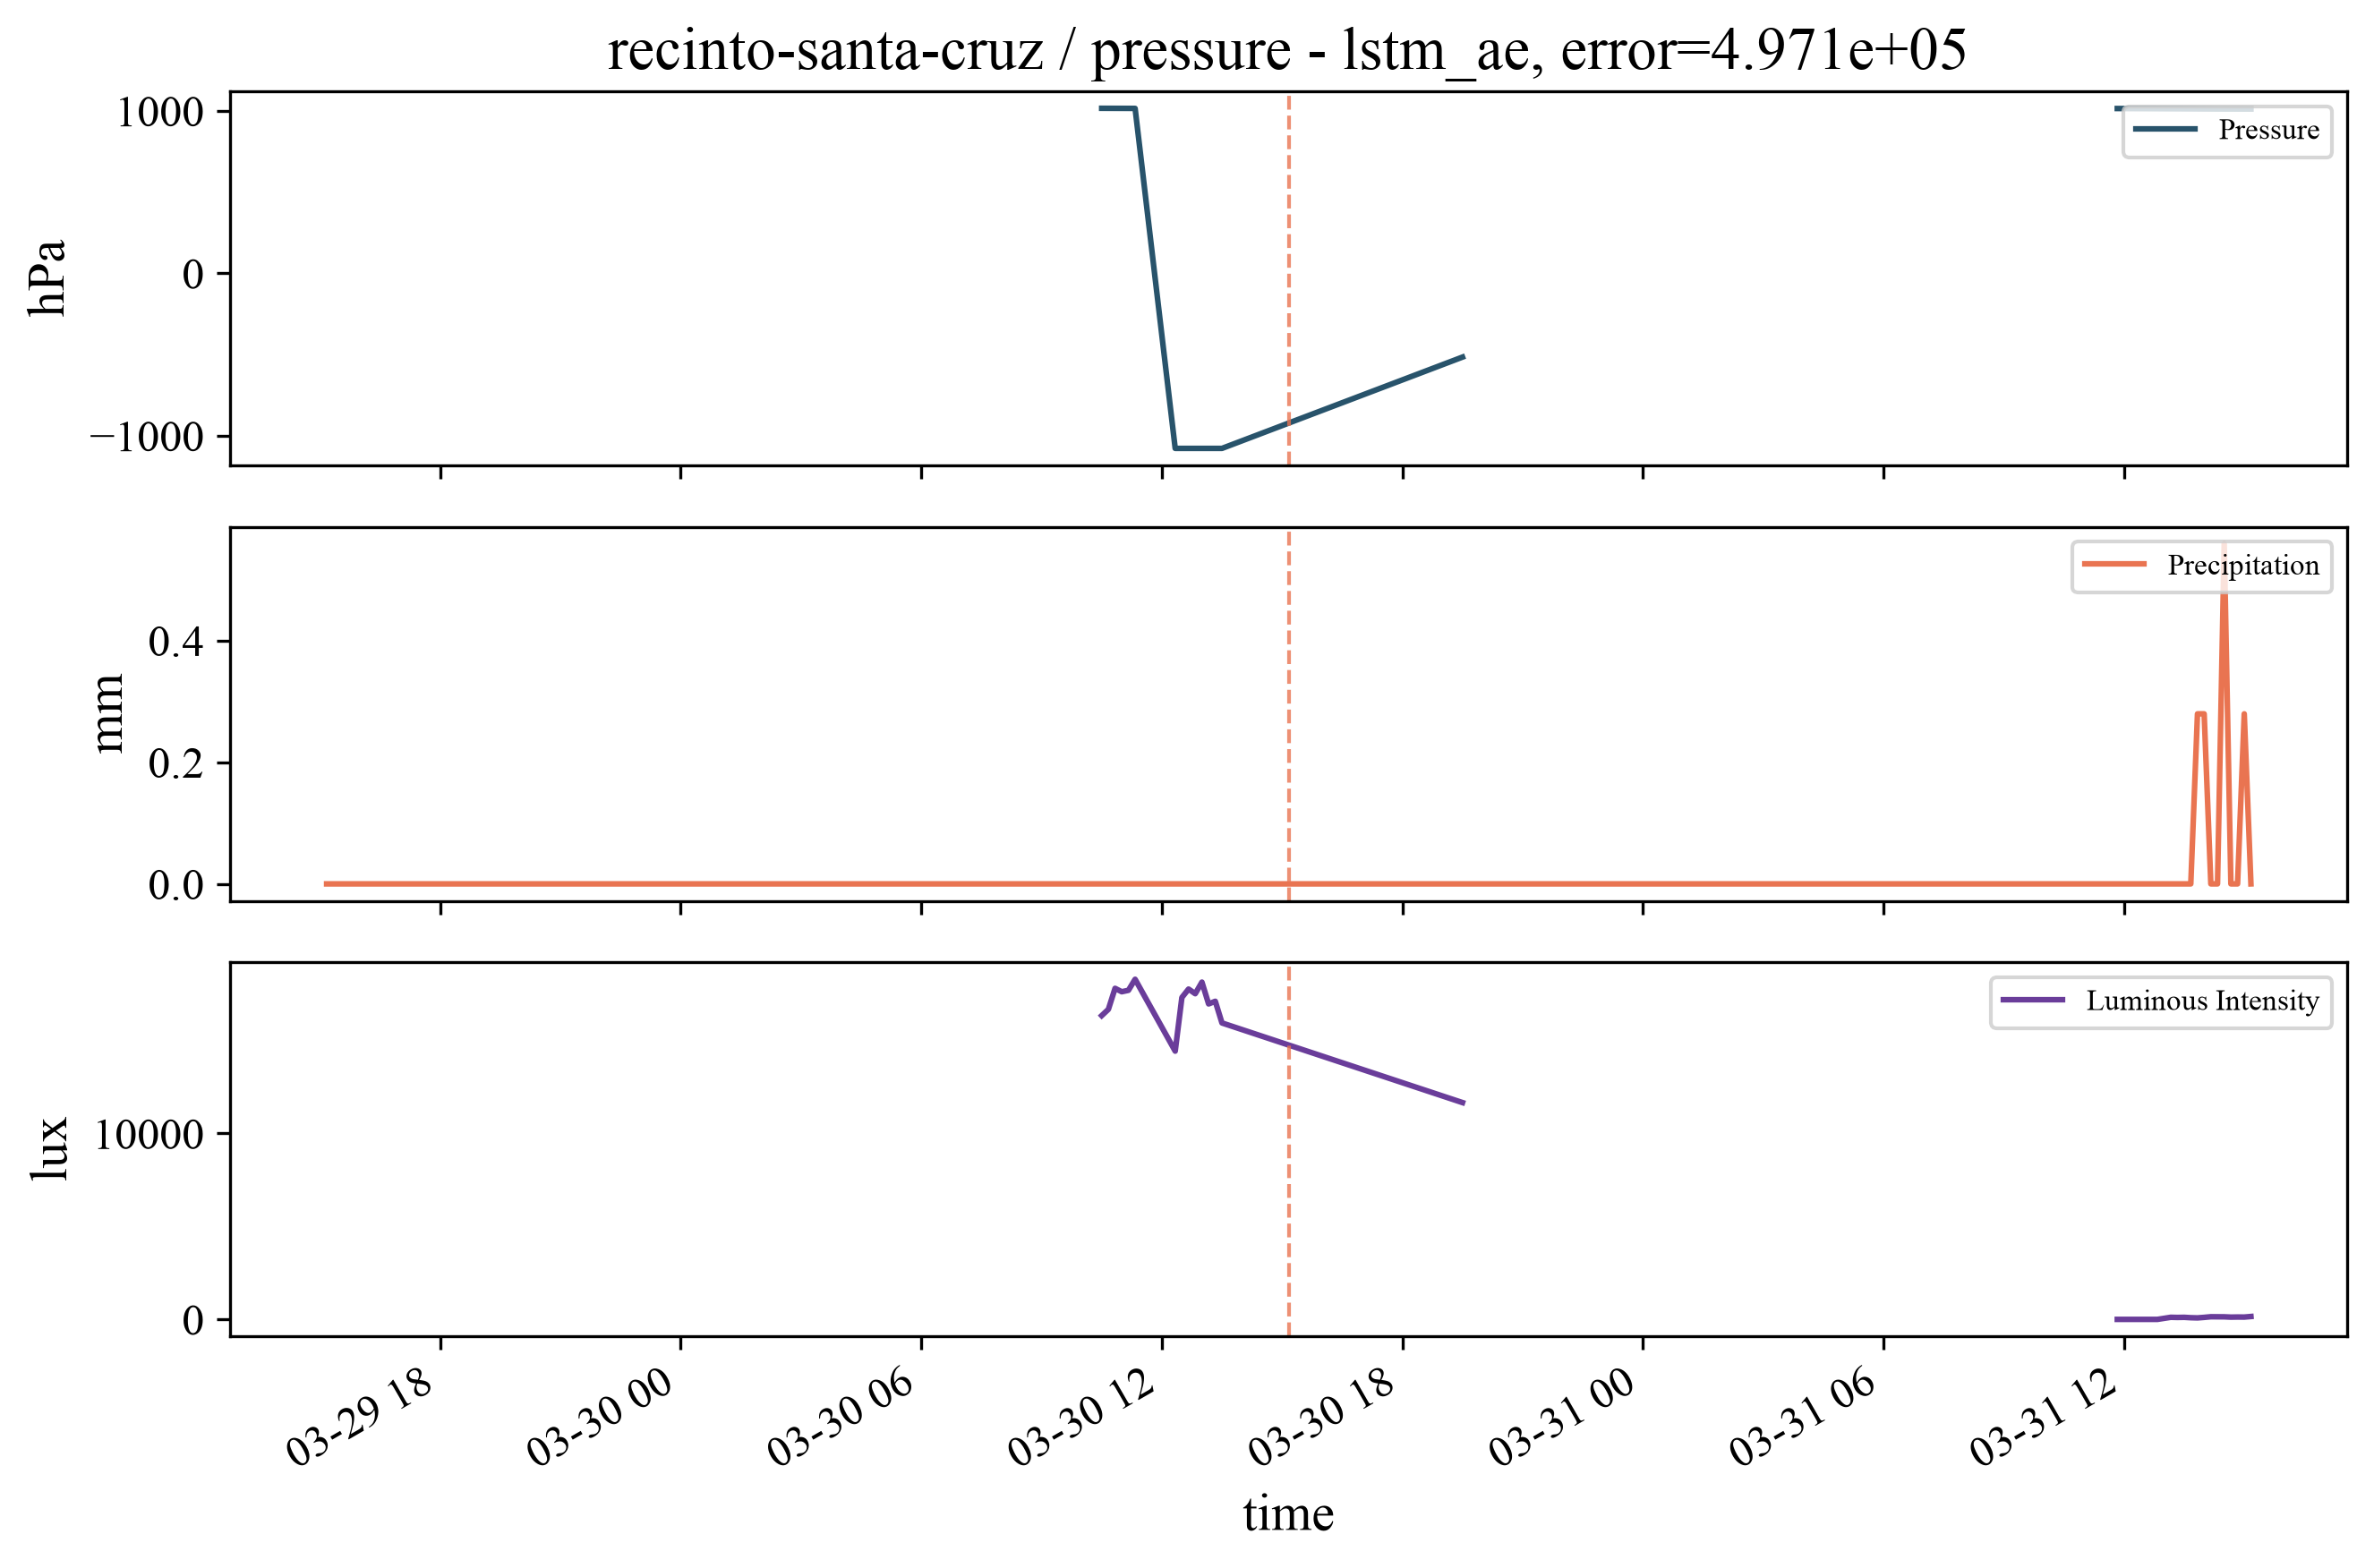

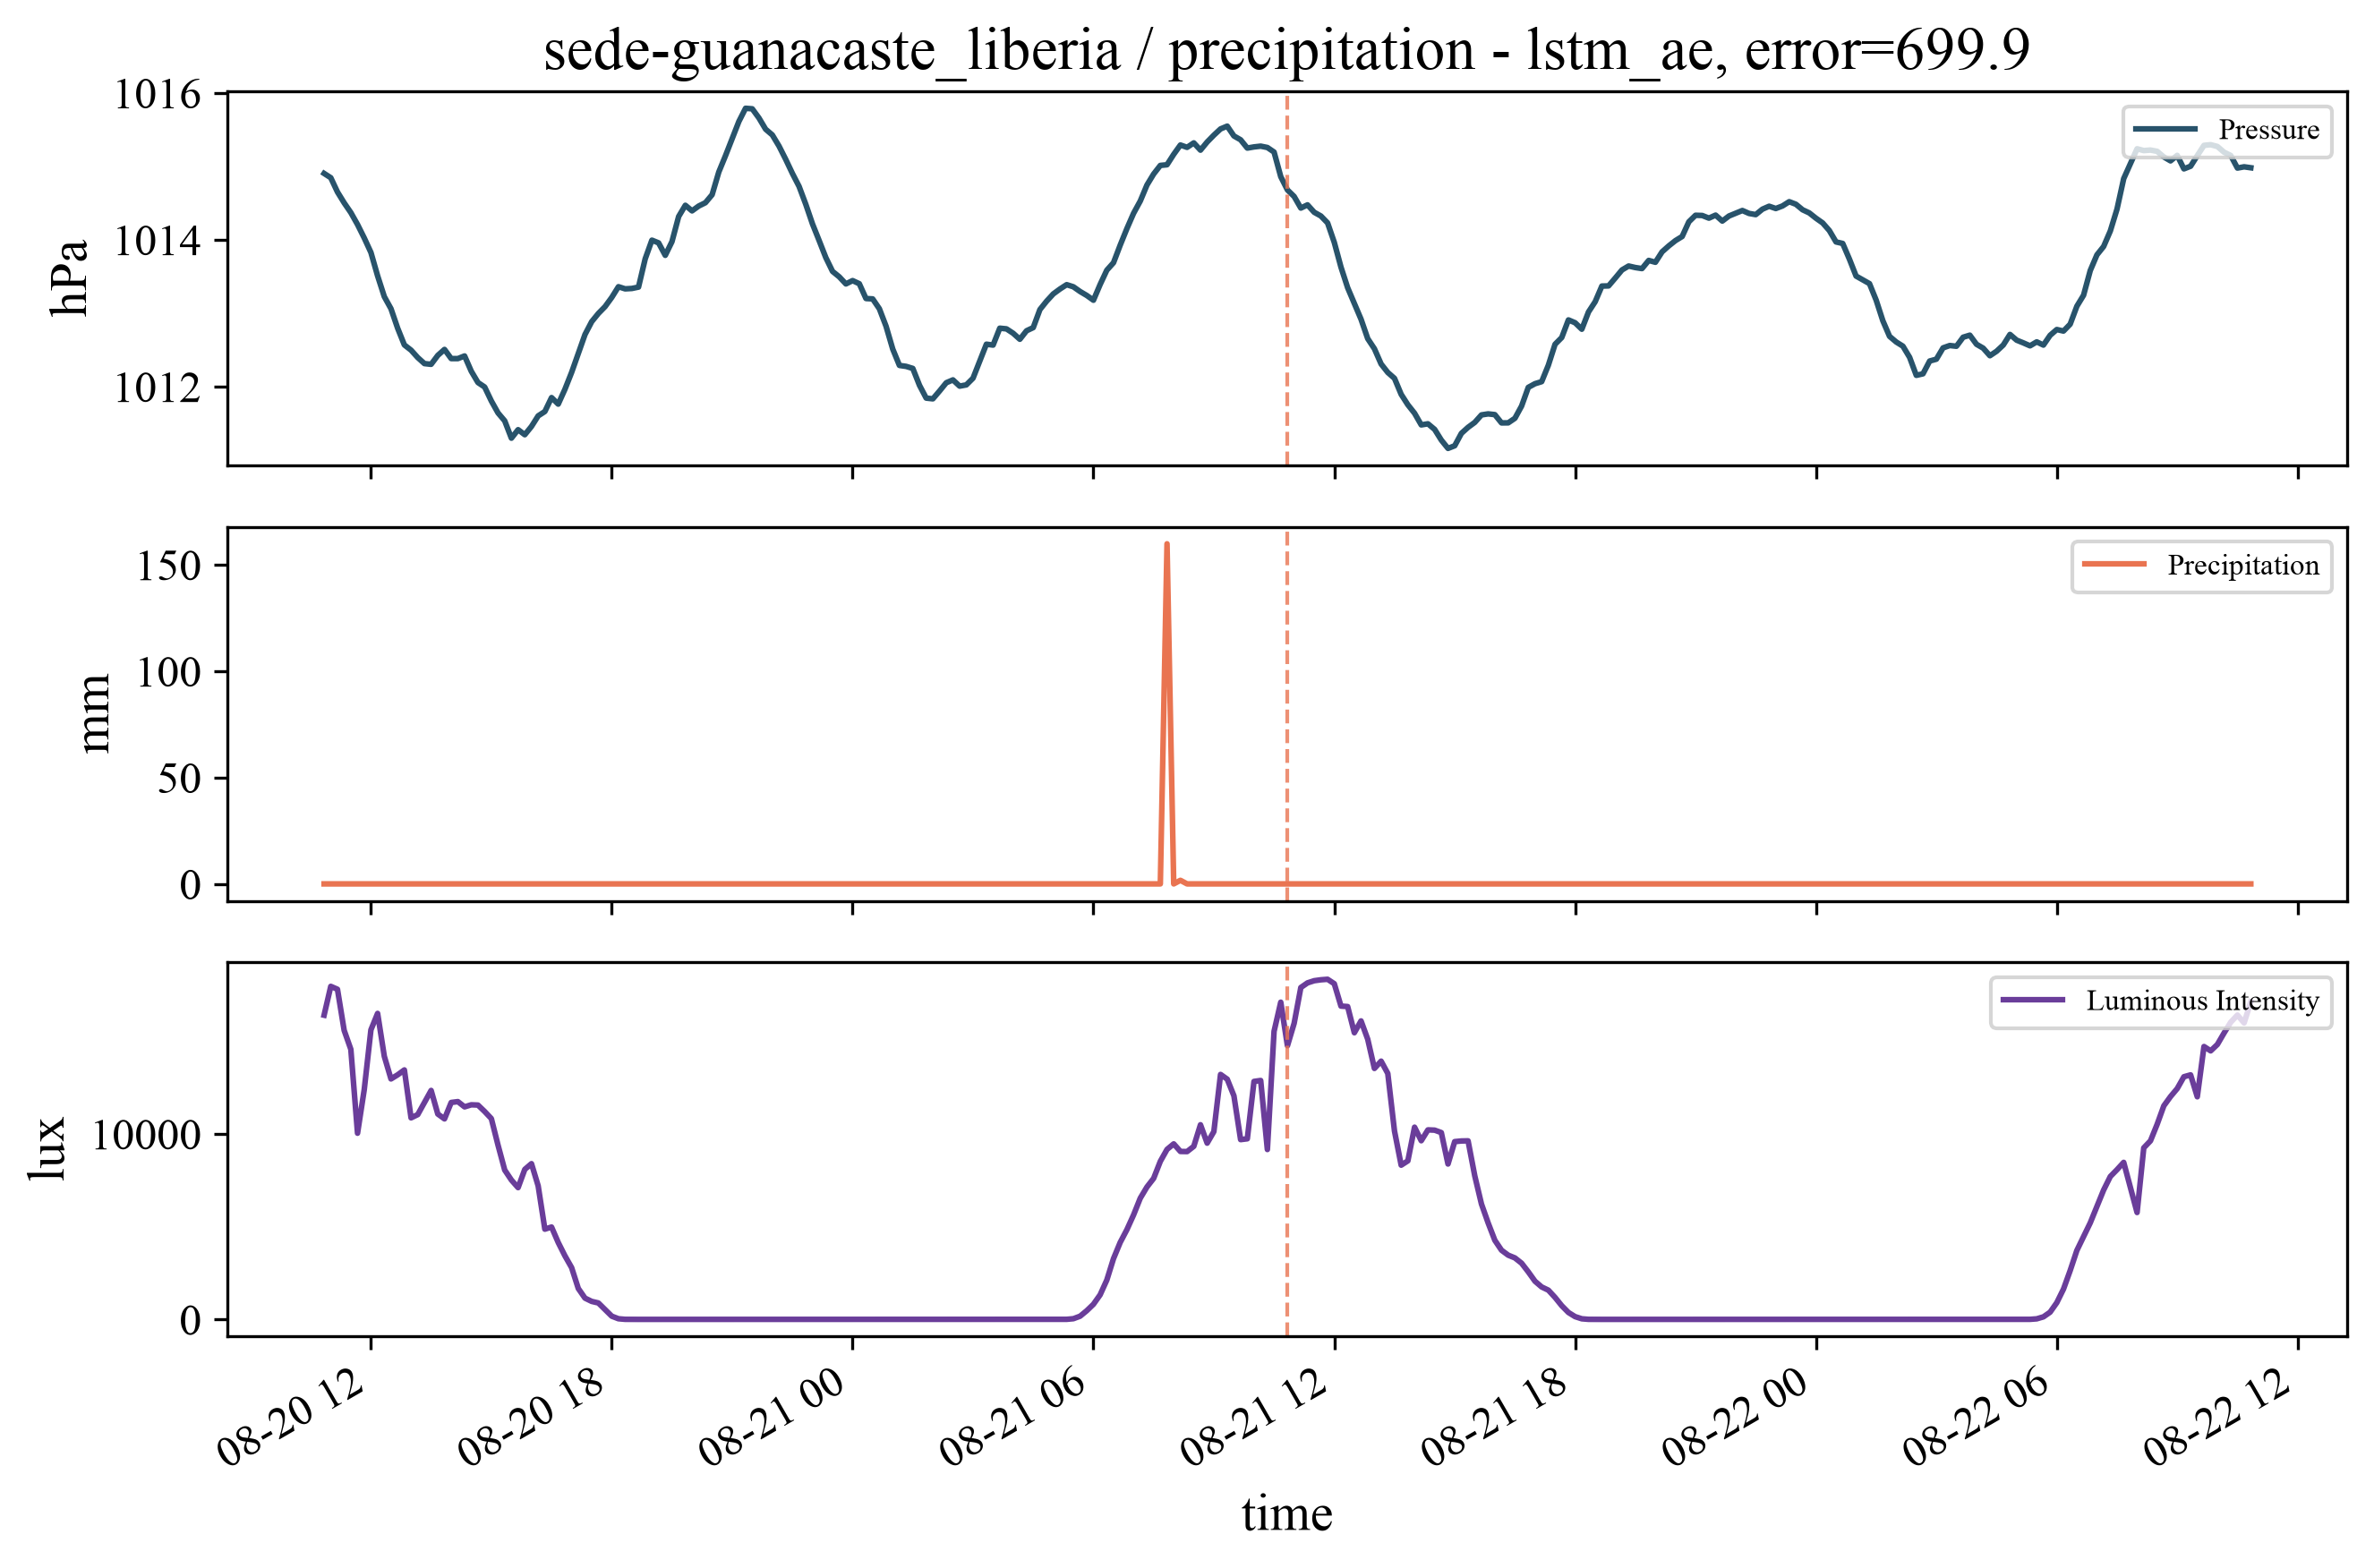

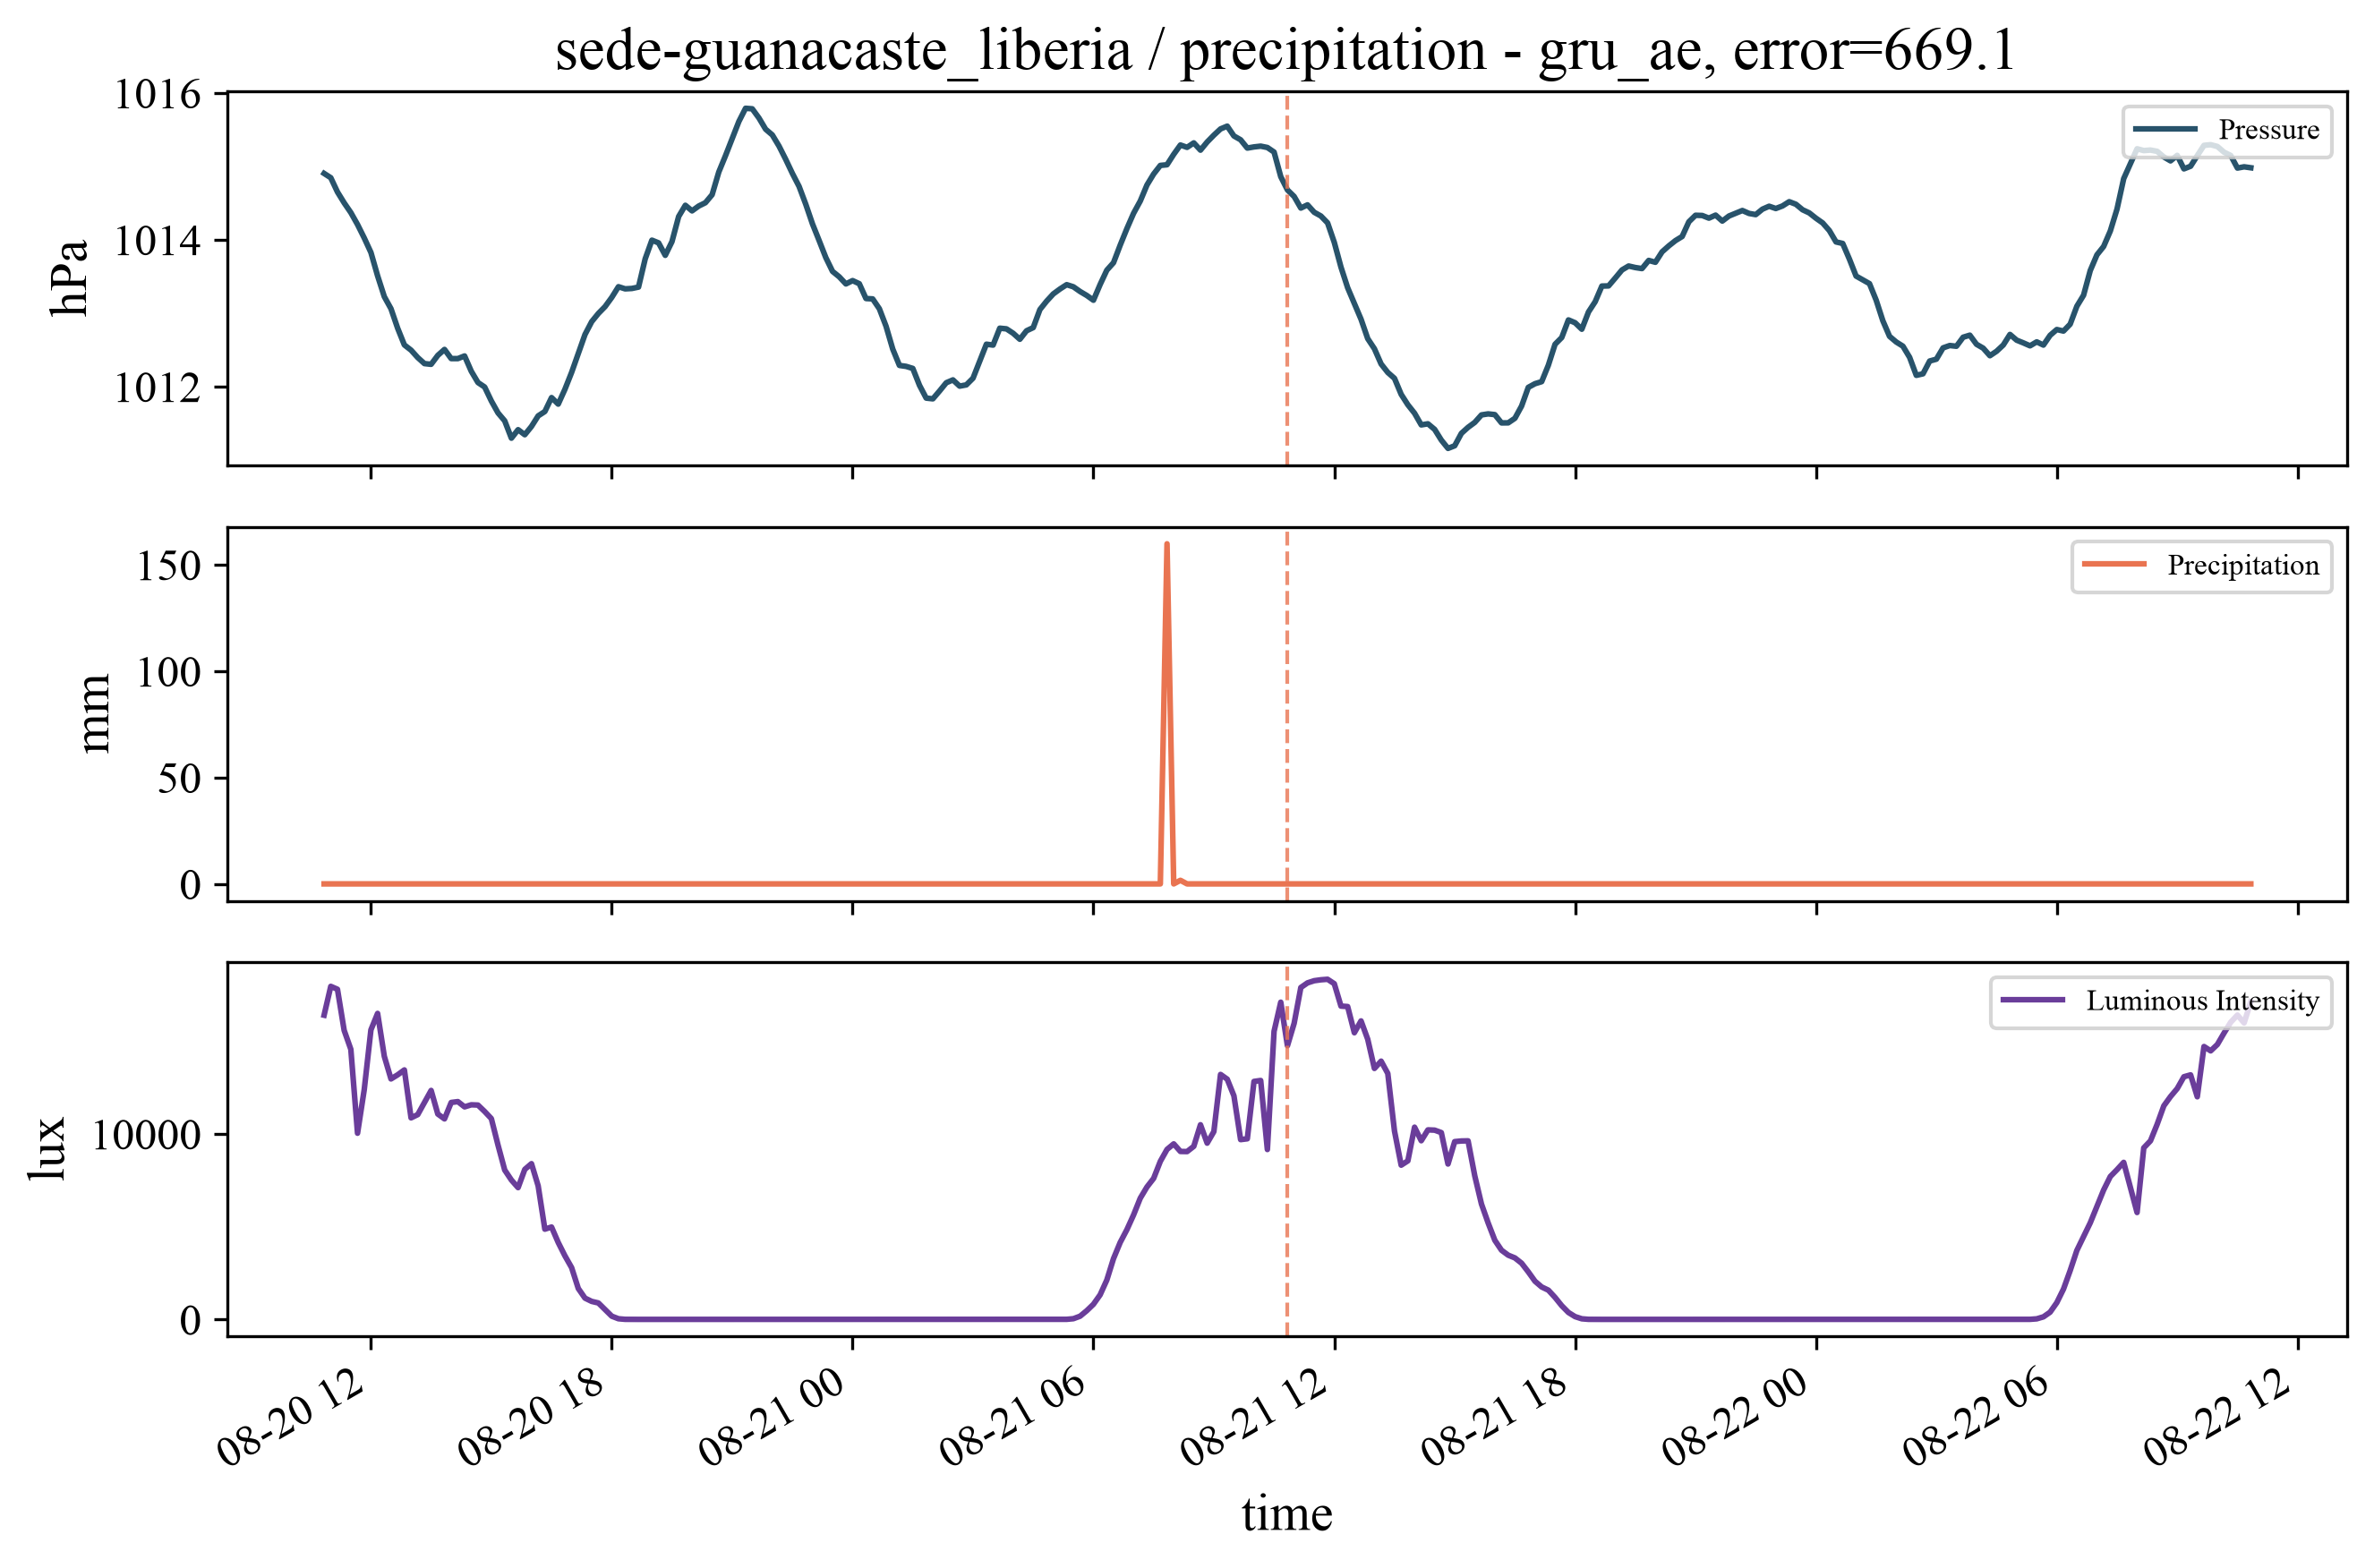

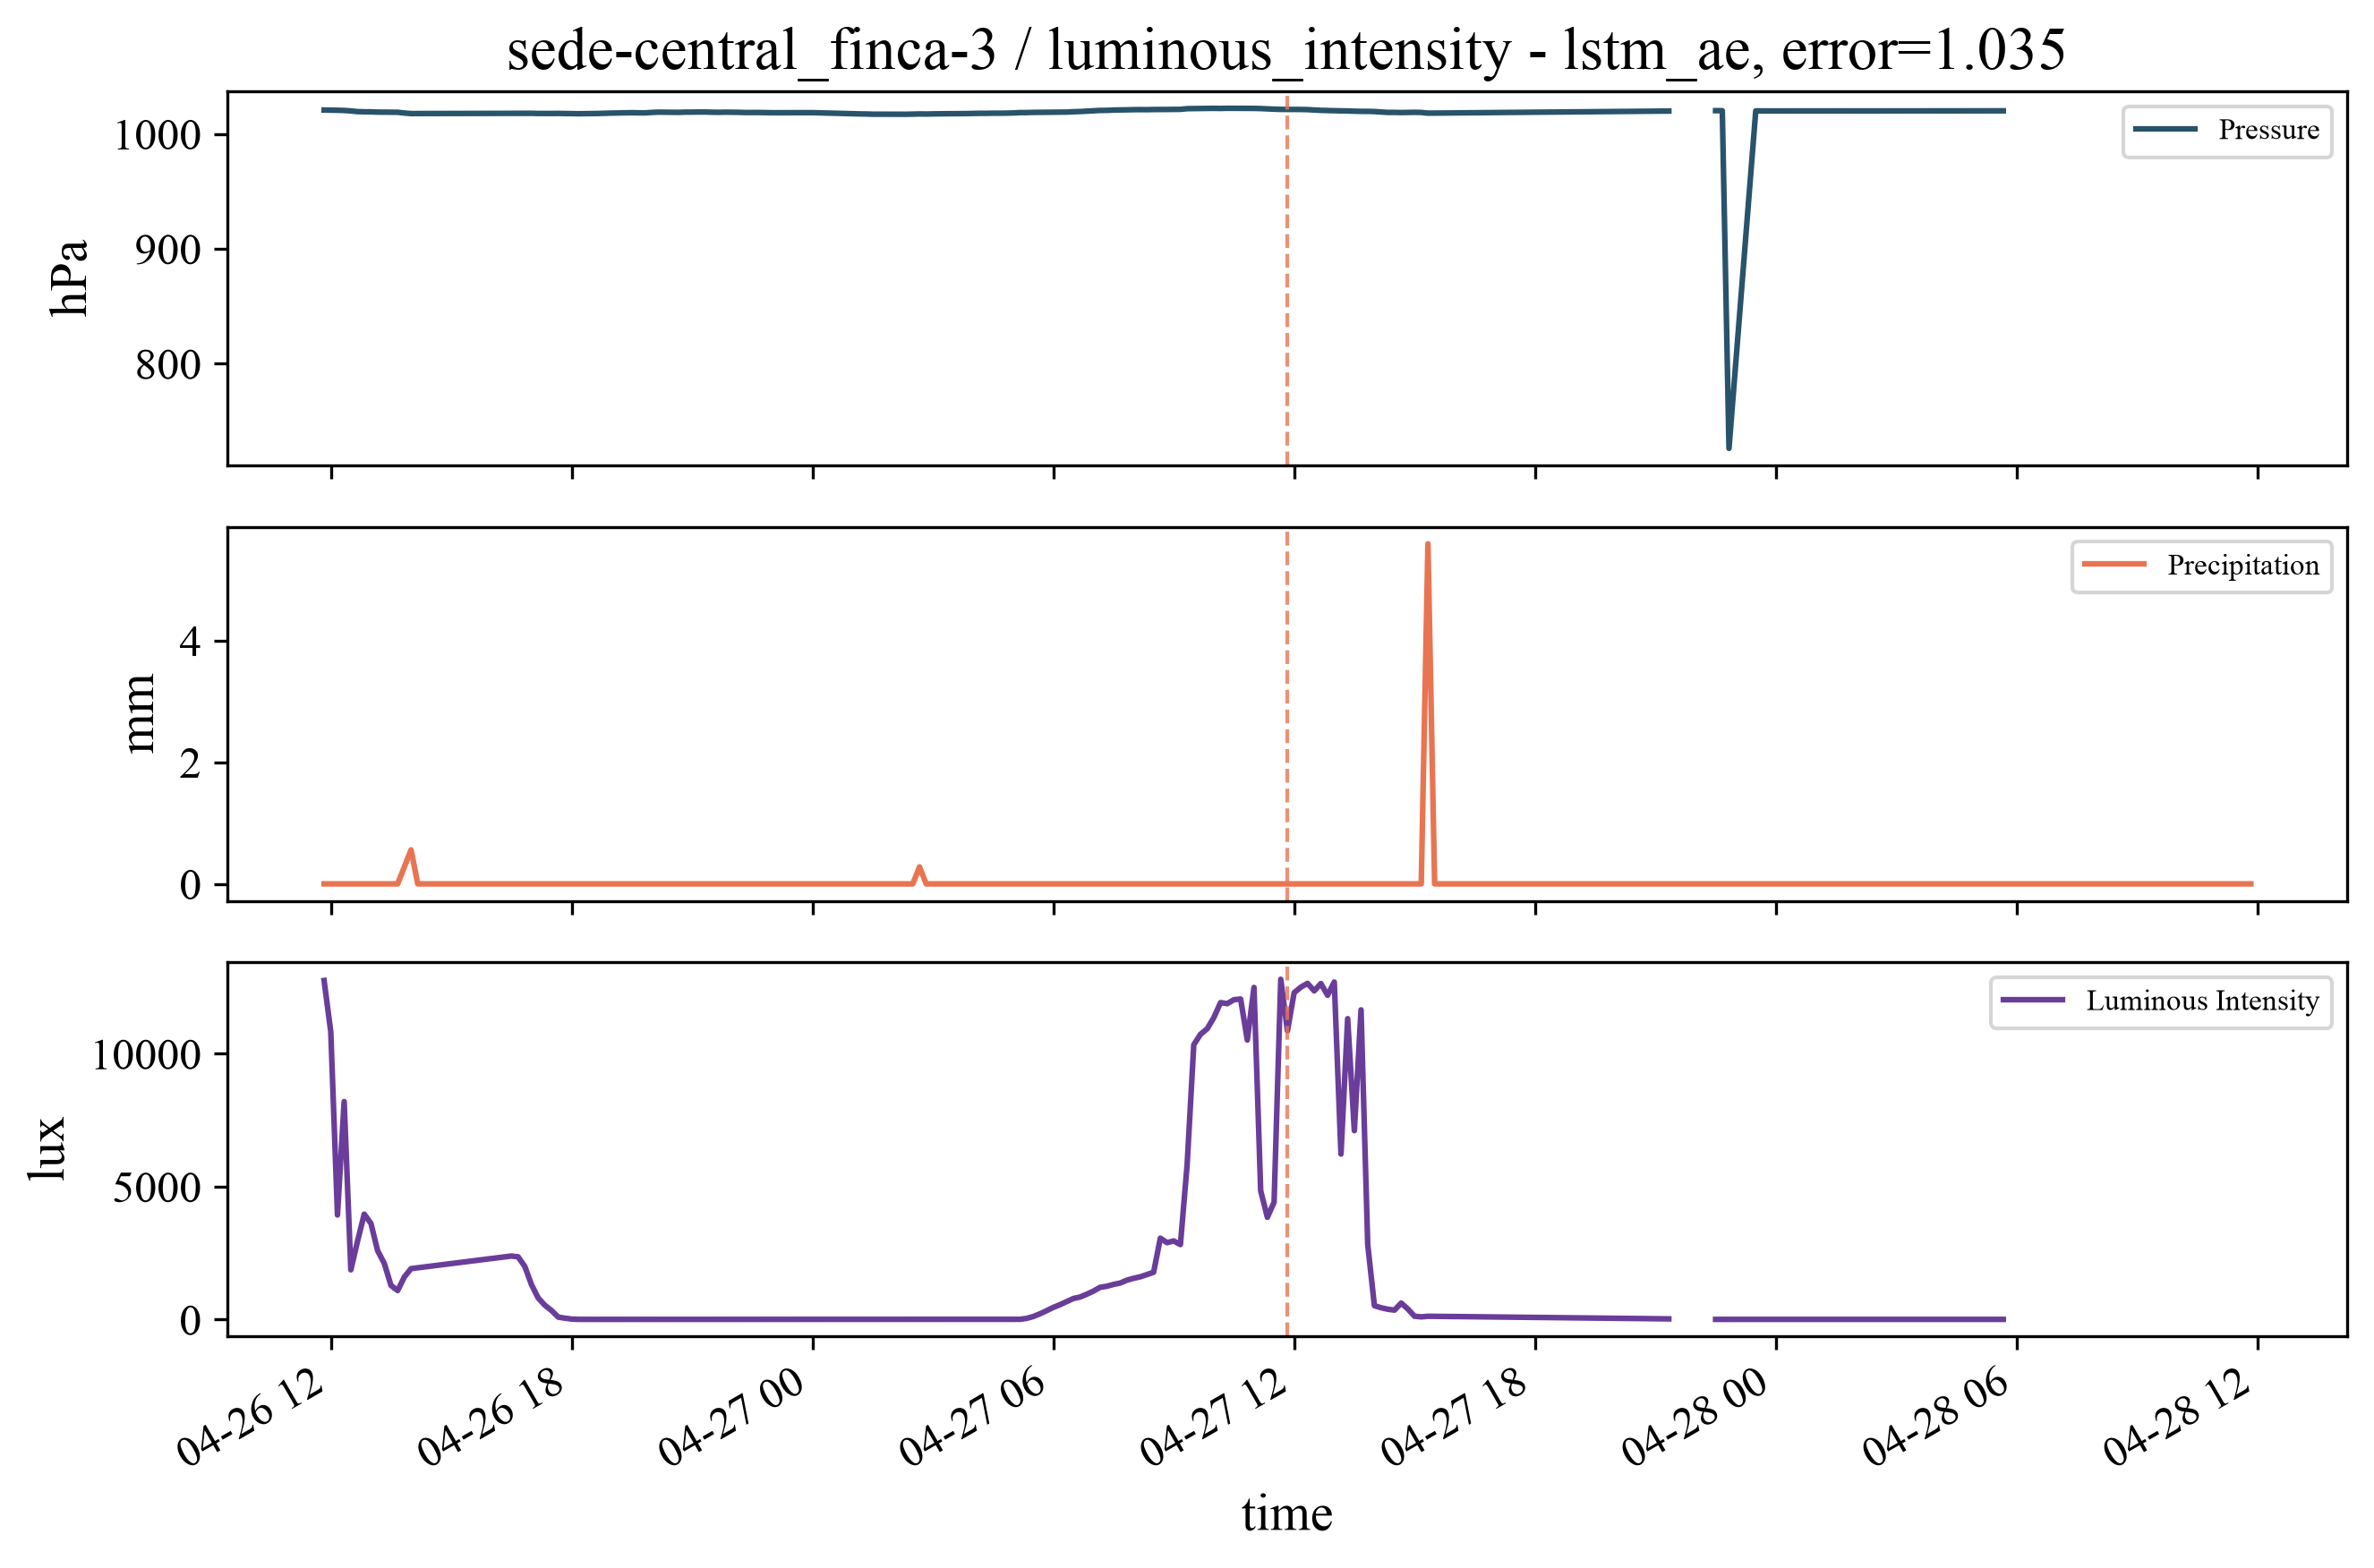

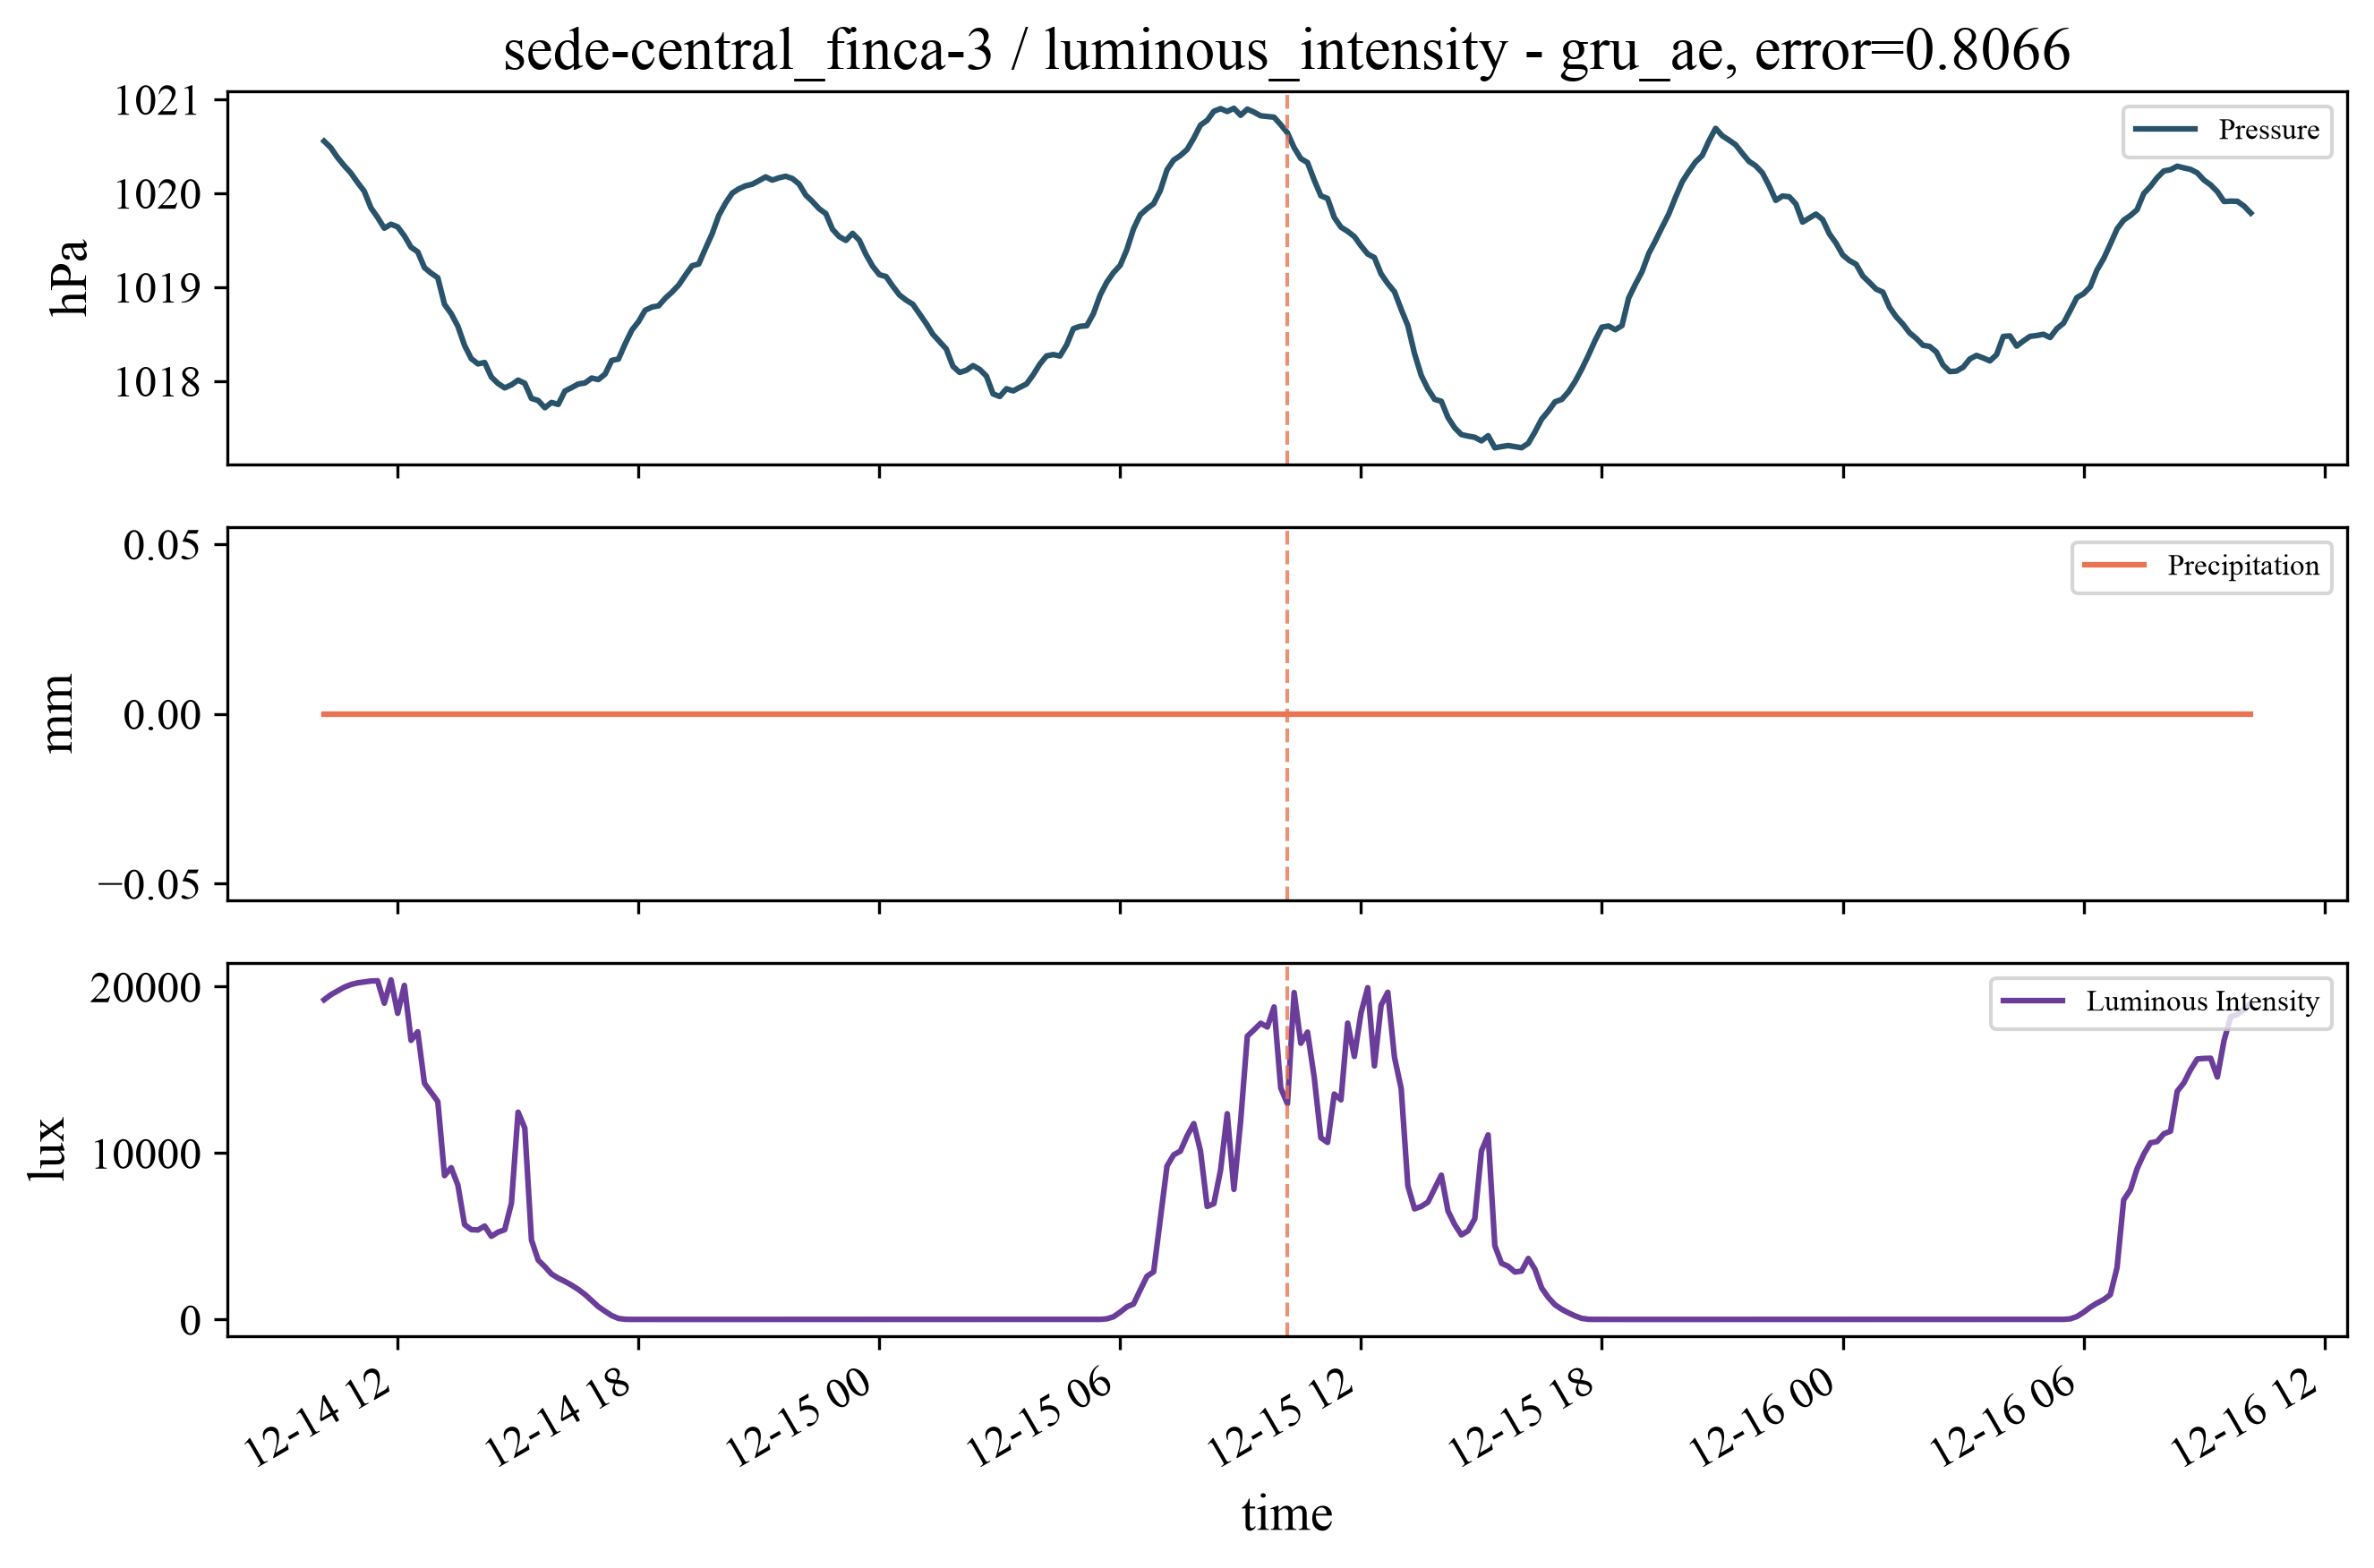

In [17]:
def plot_flagged(station, sensor, center, score, method, half_span=pd.Timedelta("24h")):
    df10 = station_frames[station]
    window = df10.loc[center - half_span : center + half_span]
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    cols = ["pressure", "precipitation", "luminous_intensity"]
    units = {"pressure": "hPa", "precipitation": "mm", "luminous_intensity": "lux"}
    for ax, col, color_name in zip(axes, cols, PALETTE_ORDER):
        ax.plot(window.index, window[col], color=PALETTE[color_name], label=pretty_label(col))
        ax.axvline(center, color=PALETTE["burnt_sienna"], linestyle="--", linewidth=1, alpha=0.8)
        ax.set_ylabel(units[col])
        ax.legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"{station} / {sensor} - {method}, error={score:.4g}")
    axes[-1].set_xlabel("time")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig


top = (
    detections[detections["flagged"]]
    .sort_values("score", ascending=False)
    .groupby(["method", "sensor"])
    .head(1)
)
for row in top.itertuples():
    fig = plot_flagged(row.station, row.sensor, row.timestamp, row.score, row.method)
    fig.savefig(DETECT_DIR / f"step6_top_flagged_{row.method}_{row.sensor}.png", bbox_inches="tight")
    plt.show()

## Closing note

All five method families are now on disk in the shared schema
(`step3_zscore_family.parquet`, `step4_density_isolation.parquet`,
`step5_autoencoder.parquet`, `step6_lstm_gru.parquet`) -- six method entries
across three sensors, and Step 7 can begin.

Nothing here is validated against ground truth, and the flagged rate above is
not evidence about how many real anomalies exist: with a percentile cutoff it
is, by construction, whatever percentile was chosen.

What carries into Step 7:

- **Six method entries, five applicable to every sensor.** `lstm_ae` and
  `gru_ae` join the roster as separate entries. `z_score_context_hour` remains
  `luminous_intensity`-only, so the pooled matrix uses `align_by_sensor` and
  the contextual variant is reported on its own channel.
- **Two methods now carry a percentile threshold rather than a published one.**
  Step 7's native-threshold view must say so rather than reading either
  flagged rate as a property of the method.
- **The seed spread bounds every claim about these two architectures**, exactly
  as it did for Step 5, and the LSTM-vs-GRU result above is stated relative to
  it rather than on its own.